In [1]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

import joblib as jb

In [2]:
data=pd.read_csv(r"C:\Projects\football_final\data\epl_final.csv")

In [3]:
data.columns

Index(['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots',
       'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
       'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
       'HomeRedCards', 'AwayRedCards'],
      dtype='str')

In [4]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [5]:
data['MatchDate']=pd.to_datetime(data['MatchDate'])

In [6]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [7]:
data = data.sort_values(by='MatchDate').reset_index(drop=True)

In [8]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0


In [9]:
data['FullTimeResult'] = data['FullTimeResult'].map({
    'H': 0,   # Home Win
    'D': 1,   # Draw
    'A': 2    # Away Win
})

In [10]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,7,2,3,6,10,11,2,2,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,2,5,1,4,15,10,2,1,0,0


In [11]:
data['GoalDiff'] = data['FullTimeHomeGoals'] - data['FullTimeAwayGoals']
data['ShotDiff'] = data['HomeShots'] - data['AwayShots']
data['ShotOnTargetDiff'] = data['HomeShotsOnTarget'] - data['AwayShotsOnTarget']
data['FoulDiff'] = data['HomeFouls'] - data['AwayFouls']
data['YellowDiff'] = data['HomeYellowCards'] - data['AwayYellowCards']
data['RedDiff'] = data['HomeRedCards'] - data['AwayRedCards']
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,1,2,0,0,4,9,10,1,-1,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,1,2,0,0,2,5,5,5,-1,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,5,3,1,0,-2,-10,-6,-6,2,1
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,1,1,0,0,0,-7,-2,-2,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,1,3,0,0,2,5,2,1,-2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,2,2,0,0,0,4,0,3,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,2,2,0,0,2,6,5,-1,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,0,2,0,0,1,-2,1,-2,-2,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,2,1,0,0,0,-8,-3,5,1,0


In [12]:
le = LabelEncoder()

data['HomeTeam_enc'] = le.fit_transform(data['HomeTeam'])
data['AwayTeam_enc'] = le.fit_transform(data['AwayTeam'])

data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeRedCards,AwayRedCards,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff,HomeTeam_enc,AwayTeam_enc
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,0,0,4,9,10,1,-1,0,12,26
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,0,0,2,5,5,5,-1,0,13,43
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,1,0,-2,-10,-6,-6,2,1,14,28
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,0,0,0,-7,-2,-2,0,0,16,36
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,0,0,2,5,2,1,-2,0,22,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,0,0,0,4,0,3,0,0,43,40
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,0,0,2,6,5,-1,0,0,13,24
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,0,0,1,-2,1,-2,-2,0,8,27
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,0,0,0,-8,-3,5,1,0,9,29


In [13]:
model = data[[
    'HomeTeam_enc',
    'AwayTeam_enc',
    'GoalDiff',
    'ShotDiff',
    'ShotOnTargetDiff',
    'FoulDiff',
    'YellowDiff',
    'RedDiff',
    'FullTimeResult'
]]
model

,HomeTeam_enc,AwayTeam_enc,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff,FullTimeResult
0,12,26,4,9,10,1,-1,0,0
1,13,43,2,5,5,5,-1,0,0
2,14,28,-2,-10,-6,-6,2,1,2
3,16,36,0,-7,-2,-2,0,0,1
4,22,17,2,5,2,1,-2,0,0
...,...,...,...,...,...,...,...,...,...
9375,43,40,0,4,0,3,0,0,1
9376,13,24,2,6,5,-1,0,0,0
9377,8,27,1,-2,1,-2,-2,0,0
9378,9,29,0,-8,-3,5,1,0,1


In [14]:
print(model.head())
print(model.isnull().sum())

   HomeTeam_enc  AwayTeam_enc  GoalDiff  ShotDiff  ShotOnTargetDiff  FoulDiff  \
0            12            26         4         9                10         1   
1            13            43         2         5                 5         5   
2            14            28        -2       -10                -6        -6   
3            16            36         0        -7                -2        -2   
4            22            17         2         5                 2         1   

   YellowDiff  RedDiff  FullTimeResult  
0          -1        0               0  
1          -1        0               0  
2           2        1               2  
3           0        0               1  
4          -2        0               0  
HomeTeam_enc        0
AwayTeam_enc        0
GoalDiff            0
ShotDiff            0
ShotOnTargetDiff    0
FoulDiff            0
YellowDiff          0
RedDiff             0
FullTimeResult      0
dtype: int64


In [15]:
team_history = defaultdict(list)

In [16]:
def get_last_n_stats(matches, n=5):
    last_matches = matches[-n:]
    
    wins, draws, losses = 0, 0, 0
    goals_scored, goals_conceded = 0, 0
    
    for m in last_matches:
        goals_scored += m['scored']
        goals_conceded += m['conceded']
        
        if m['result'] == 'W':
            wins += 1
        elif m['result'] == 'D':
            draws += 1
        else:
            losses += 1
    
    total = len(last_matches)
    
    if total == 0:
        return [0]*6
    
    return [
        wins,
        draws,
        losses,
        goals_scored / total,
        goals_conceded / total,
        (wins*3 + draws) / total   # avg points
    ]

In [17]:
elo = defaultdict(lambda: 1500) 
K = 30
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
print(expected_score(1500, 1500))

0.5


In [18]:
features = []

for i, row in data.iterrows():
    
    home = row['HomeTeam']
    away = row['AwayTeam']
    
    # get past stats BEFORE this match
    home_stats = get_last_n_stats(team_history[home])
    away_stats = get_last_n_stats(team_history[away])
    home_elo = elo[home]
    away_elo = elo[away]
    elo_diff = home_elo - away_elo
    features.append(home_stats + away_stats+[home_elo, away_elo, elo_diff])
    
    # ----- NOW update history AFTER computing features -----
    # Home team result
    if row['FullTimeHomeGoals'] > row['FullTimeAwayGoals']:
        home_result = 1
        away_result = 0
        h_res, a_res = 'W', 'L'
        
    elif row['FullTimeHomeGoals'] < row['FullTimeAwayGoals']:
        home_result = 0
        away_result = 1
        h_res, a_res = 'L', 'W'
        
    else:
        home_result = away_result = 0.5
        h_res = a_res = 'D'
    
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)
    
    
    elo[home] += K * (home_result - expected_home)
    elo[away] += K * (away_result - expected_away)
    
    # update home team history
    team_history[home].append({
        'scored': row['FullTimeHomeGoals'],
        'conceded': row['FullTimeAwayGoals'],
        'result': home_result
    })
    
    # update away team history
    team_history[away].append({
        'scored': row['FullTimeAwayGoals'],
        'conceded': row['FullTimeHomeGoals'],
        'result': away_result
    })

In [19]:
features

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1500, 1500, 0],
 [0, 0, 1, 0.0, 1.0, 0.0, 0, 0, 1, 1.0, 0.0, 0.0, 1485.0, 1515.0, -30.0],
 [0, 0, 1, 0.0, 1.0, 0.0, 0, 0, 1, 4.0, 2.0, 0.0, 1485.0, 1515.0, -30.0],
 [0, 0, 1, 1.0, 3.0, 0.0, 0, 0, 1, 2.0, 0.0, 0.0, 1485.0, 1515.0, -30.0],
 [0, 0, 1, 3.0, 1.0, 0.0, 0, 0, 1, 3.0, 1.0, 0.0, 1515.0, 1515.0, 0.0],
 [0, 0, 1, 2.0, 4.0, 0.0, 0, 0, 1, 0.0, 0.0, 0.0, 1485.0, 1500.0, -15.0],
 [0, 0, 1, 0.0, 2.0, 0.0, 0, 0, 1, 2.0, 2.0, 0.0, 1485.0, 1500.0, -15.0],
 [0, 0, 1, 2.0, 2.

In [20]:
feature_cols = [
    'home_wins', 'home_draws', 'home_losses',
    'home_avg_scored', 'home_avg_conceded', 'home_avg_points',
    
    'away_wins', 'away_draws', 'away_losses',
    'away_avg_scored', 'away_avg_conceded', 'away_avg_points',
    
    'home_elo', 'away_elo', 'elo_diff'
]

X = pd.DataFrame(features, columns=feature_cols)
Y = data['FullTimeResult']

In [21]:
Y

0       0
1       0
2       2
3       1
4       0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 9380, dtype: int64

In [22]:
X=X.iloc[50:]
Y=Y.iloc[50:]

In [23]:
X

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
50,0,0,4,1.25,0.75,0.0,0,0,5,1.0,1.6,0.0,1512.585649,1472.236955,40.348694
51,0,0,5,1.80,1.60,0.0,0,0,5,2.8,0.6,0.0,1501.107750,1539.549207,-38.441457
52,0,0,5,1.40,1.80,0.0,0,0,5,1.4,0.8,0.0,1471.784388,1529.875050,-58.090662
53,0,0,4,1.00,1.25,0.0,0,0,5,0.6,1.6,0.0,1499.971172,1488.499673,11.471499
54,0,0,5,2.00,1.40,0.0,0,0,5,1.0,1.4,0.0,1514.216801,1501.236608,12.980193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.20,1.80,0.0,0,0,5,1.4,2.6,0.0,1523.788808,1523.865952,-0.077143
9376,0,0,5,1.20,0.60,0.0,0,0,5,2.2,1.0,0.0,1677.684060,1835.617108,-157.933048
9377,0,0,5,1.60,1.00,0.0,0,0,5,0.4,1.4,0.0,1621.041828,1564.014765,57.027063
9378,0,0,5,1.60,2.60,0.0,0,0,5,3.2,1.0,0.0,1609.713603,1694.678778,-84.965175


In [24]:
Y

50      2
51      2
52      0
53      0
54      0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 9330, dtype: int64

In [25]:
X_train = X.loc[data['MatchDate'] < '2021-01-01']
X_test  = X.loc[data['MatchDate'] >= '2021-01-01']

Y_train = Y.loc[data['MatchDate'] < '2021-01-01']
Y_test  = Y.loc[data['MatchDate'] >= '2021-01-01']

In [26]:
X

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
50,0,0,4,1.25,0.75,0.0,0,0,5,1.0,1.6,0.0,1512.585649,1472.236955,40.348694
51,0,0,5,1.80,1.60,0.0,0,0,5,2.8,0.6,0.0,1501.107750,1539.549207,-38.441457
52,0,0,5,1.40,1.80,0.0,0,0,5,1.4,0.8,0.0,1471.784388,1529.875050,-58.090662
53,0,0,4,1.00,1.25,0.0,0,0,5,0.6,1.6,0.0,1499.971172,1488.499673,11.471499
54,0,0,5,2.00,1.40,0.0,0,0,5,1.0,1.4,0.0,1514.216801,1501.236608,12.980193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.20,1.80,0.0,0,0,5,1.4,2.6,0.0,1523.788808,1523.865952,-0.077143
9376,0,0,5,1.20,0.60,0.0,0,0,5,2.2,1.0,0.0,1677.684060,1835.617108,-157.933048
9377,0,0,5,1.60,1.00,0.0,0,0,5,0.4,1.4,0.0,1621.041828,1564.014765,57.027063
9378,0,0,5,1.60,2.60,0.0,0,0,5,3.2,1.0,0.0,1609.713603,1694.678778,-84.965175


In [27]:
X_train

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
50,0,0,4,1.25,0.75,0.0,0,0,5,1.0,1.6,0.0,1512.585649,1472.236955,40.348694
51,0,0,5,1.80,1.60,0.0,0,0,5,2.8,0.6,0.0,1501.107750,1539.549207,-38.441457
52,0,0,5,1.40,1.80,0.0,0,0,5,1.4,0.8,0.0,1471.784388,1529.875050,-58.090662
53,0,0,4,1.00,1.25,0.0,0,0,5,0.6,1.6,0.0,1499.971172,1488.499673,11.471499
54,0,0,5,2.00,1.40,0.0,0,0,5,1.0,1.4,0.0,1514.216801,1501.236608,12.980193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7660,0,0,5,0.80,2.40,0.0,0,0,5,2.0,2.6,0.0,1435.931791,1487.632862,-51.701071
7661,0,0,5,0.80,0.60,0.0,0,0,5,0.8,2.0,0.0,1546.732009,1422.982469,123.749539
7662,0,0,5,1.20,0.60,0.0,0,0,5,1.2,2.0,0.0,1612.056374,1562.531601,49.524773
7663,0,0,5,0.80,1.60,0.0,0,0,5,1.0,1.4,0.0,1498.623532,1579.291974,-80.668442


In [28]:
X_test

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
7665,0,0,5,1.4,0.4,0.0,0,0,5,1.0,1.4,0.0,1627.159523,1564.655393,62.504131
7666,0,0,5,2.4,1.2,0.0,0,0,5,1.6,0.2,0.0,1722.415451,1543.206578,179.208873
7667,0,0,5,0.6,1.4,0.0,0,0,5,0.8,1.2,0.0,1487.045006,1595.815467,-108.770461
7668,0,0,5,0.6,2.4,0.0,0,0,5,1.2,1.0,0.0,1423.147575,1590.870500,-167.722925
7669,0,0,5,1.0,1.2,0.0,0,0,5,2.8,2.0,0.0,1666.346190,1500.417079,165.929112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.2,1.8,0.0,0,0,5,1.4,2.6,0.0,1523.788808,1523.865952,-0.077143
9376,0,0,5,1.2,0.6,0.0,0,0,5,2.2,1.0,0.0,1677.684060,1835.617108,-157.933048
9377,0,0,5,1.6,1.0,0.0,0,0,5,0.4,1.4,0.0,1621.041828,1564.014765,57.027063
9378,0,0,5,1.6,2.6,0.0,0,0,5,3.2,1.0,0.0,1609.713603,1694.678778,-84.965175


In [29]:
Y_train

50      2
51      2
52      0
53      0
54      0
       ..
7660    2
7661    0
7662    1
7663    2
7664    1
Name: FullTimeResult, Length: 7615, dtype: int64

In [30]:
Y_test

7665    2
7666    0
7667    1
7668    2
7669    0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 1715, dtype: int64

In [31]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(7615, 15) (1715, 15)
(7615,) (1715,)


In [32]:
tscv = TimeSeriesSplit(n_splits=5)
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_elo = RandomForestClassifier(random_state=42)

search_rf_elo = RandomizedSearchCV(
    estimator=rf_elo,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_rf_elo.fit(X, Y)
model = search_rf_elo.best_estimator_
model.fit(X_train, Y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [33]:
Y_pred = model.predict(X_test)

In [34]:
Y_pred

array([0, 0, 2, ..., 0, 2, 0], shape=(1715,))

In [35]:
# work of scikit learn

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5416909620991254
[[648   0 105]
 [270   0 119]
 [292   0 281]]
              precision    recall  f1-score   support

           0       0.54      0.86      0.66       753
           1       0.00      0.00      0.00       389
           2       0.56      0.49      0.52       573

    accuracy                           0.54      1715
   macro avg       0.36      0.45      0.39      1715
weighted avg       0.42      0.54      0.46      1715



c:\Projects\football_final\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projects\football_final\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projects\football_final\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [36]:
accuracy_rf_elo = accuracy_score(Y_test, Y_pred)

<Axes: >

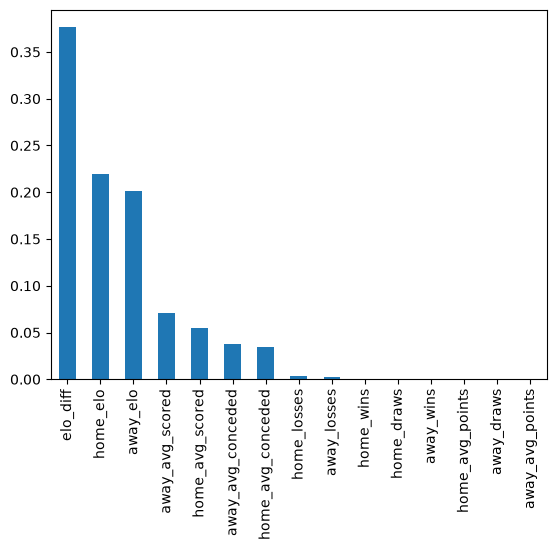

In [37]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')

In [38]:
print(Y.value_counts())

FullTimeResult
0    4275
2    2759
1    2296
Name: count, dtype: int64


In [39]:
y_home = data['FullTimeHomeGoals']
y_away = data['FullTimeAwayGoals']

y_home = y_home.iloc[50:]
y_away = y_away.iloc[50:]

y_home_train = y_home.loc[data['MatchDate'] < '2021-01-01']
y_home_test = y_home.loc[data['MatchDate'] >= '2021-01-01']

y_away_train = y_away.loc[data['MatchDate'] < '2021-01-01']
y_away_test = y_away.loc[data['MatchDate'] >= '2021-01-01']

param_dist_reg = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_reg=RandomForestRegressor(random_state=42)

search_home = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist_reg,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_away = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist_reg,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_home.fit(X,y_home)
search_away.fit(X,y_away)

home_goal_model_elo = search_home.best_estimator_

home_goal_model_elo.fit(X_train, y_home_train)

away_goal_model_elo = search_away.best_estimator_

away_goal_model_elo.fit(X_train, y_away_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [40]:
home_pred = home_goal_model_elo.predict(X_test)

print(
    "Home Goal MAE:",
    mean_absolute_error(y_home_test, home_pred)
)
away_pred = away_goal_model_elo.predict(X_test)

print(
    "Away Goal MAE:",
    mean_absolute_error(y_away_test, away_pred)
)

Home Goal MAE: 0.9842234954726656
Away Goal MAE: 0.9010421789483954


In [41]:
mae = [mean_absolute_error(y_home_test, home_pred), mean_absolute_error(y_away_test, away_pred)]

In [42]:
# cell functions not needed here, but written anyway

def create_match_features_elo(home_team, away_team):

    home_stats = get_last_n_stats(team_history[home_team])
    away_stats = get_last_n_stats(team_history[away_team])

    # Same home advantage used during training
    home_elo = elo[home_team] + 100
    away_elo = elo[away_team]

    elo_diff = home_elo - away_elo

    features = (
        home_stats
        + away_stats
        + [home_elo, away_elo, elo_diff]
    )

    return pd.DataFrame(
        [features],
        columns=feature_cols
    )


def predict_match_elo(home_team, away_team):

    if home_team not in team_history:
        print(f"{home_team} not found")
        return

    if away_team not in team_history:
        print(f"{away_team} not found")
        return

    features = create_match_features_elo(
        home_team,
        away_team
    )

    # Match outcome probabilities
    probs = model.predict_proba(features)[0]

    home_win_prob = probs[0]
    draw_prob = probs[1]
    away_win_prob = probs[2]

    # Predicted outcome
    pred = model.predict(features)[0]

    outcome_map = {
        0: "Home Win",
        1: "Draw",
        2: "Away Win"
    }

    # Goal predictions
    home_goals = home_goal_model_elo.predict(features)[0]
    away_goals = away_goal_model_elo.predict(features)[0]

    predicted_home_score = max(0, round(home_goals))
    predicted_away_score = max(0, round(away_goals))

    print("\n" + "=" * 50)
    print(f"HOME : {home_team}")
    print(f"AWAY : {away_team}")
    print("=" * 50)

    print("\nWin Probabilities")

    print(f"Home Win : {home_win_prob*100:.2f}%")
    print(f"Draw     : {draw_prob*100:.2f}%")
    print(f"Away Win : {away_win_prob*100:.2f}%")

    print("\nPredicted Outcome")
    print(outcome_map[pred])

    print("\nExpected Goals")

    print(f"{home_team}: {home_goals:.2f}")
    print(f"{away_team}: {away_goals:.2f}")

    print(
        f"\nPredicted Score: "
        f"{predicted_home_score}-{predicted_away_score}"
    )

    print("\nCurrent ELO Ratings")

    print(f"{home_team}: {elo[home_team]:.1f}")
    print(f"{away_team}: {elo[away_team]:.1f}")

    print("=" * 50)
predict_match_elo(
    "Man City",
    "Everton"
)

predict_match_elo("Arsenal","Everton")


HOME : Man City
AWAY : Everton

Win Probabilities
Home Win : 72.56%
Draw     : 18.01%
Away Win : 9.42%

Predicted Outcome
Home Win

Expected Goals
Man City: 2.32
Everton: 0.80

Predicted Score: 2-1

Current ELO Ratings
Man City: 1776.5
Everton: 1582.3

HOME : Arsenal
AWAY : Everton

Win Probabilities
Home Win : 69.10%
Draw     : 19.59%
Away Win : 11.31%

Predicted Outcome
Home Win

Expected Goals
Arsenal: 2.27
Everton: 0.81

Predicted Score: 2-1

Current ELO Ratings
Arsenal: 1758.8
Everton: 1582.3


In [43]:
# cell functions not needed here, but written anyway

def predict_match_elo_st(home_team, away_team):
    features_st = create_match_features_elo(home_team, away_team)

    # Classification probabilities
    probs_st = model.predict_proba(features_st)[0]

    home_win_prob_st = round(probs_st[0], 2)
    draw_prob_st = round(probs_st[1], 2)
    away_win_prob_st = round(probs_st[2], 2)

    # Goal predictions
    home_goals_st = home_goal_model_elo.predict(features_st)[0]
    away_goals_st = away_goal_model_elo.predict(features_st)[0]

    # Make score realistic
    predicted_home_st = max(0, round(home_goals_st))
    predicted_away_st = max(0, round(away_goals_st))

    return[
        home_win_prob_st,
        draw_prob_st,
        away_win_prob_st,
        predicted_home_st,
        predicted_away_st
    ]

In [44]:
elo_dict = dict(elo)

In [45]:
jb.dump(elo_dict, r"C:\Projects\football_final\training\dumped_models_vars\elo_all.joblib")

jb.dump(model, r"C:\Projects\football_final\training\dumped_models_vars\rf_elo_model.joblib")
jb.dump(home_goal_model_elo, r"C:\Projects\football_final\training\dumped_models_vars\rf_elo_home_goal_model.joblib")
jb.dump(away_goal_model_elo, r"C:\Projects\football_final\training\dumped_models_vars\rf_elo_away_goal_model.joblib")

jb.dump(accuracy_rf_elo, r"C:\Projects\football_final\training\dumped_models_vars\rf_elo_acc.joblib")

['C:\\Projects\\football_final\\training\\dumped_models_vars\\rf_elo_acc.joblib']

In [46]:
jb.dump(mae, r"C:\Projects\football_final\training\dumped_models_vars\mae_rf_elo.joblib")

['C:\\Projects\\football_final\\training\\dumped_models_vars\\mae_rf_elo.joblib']